In [6]:
import json

# Load the GEOJSON data from your file
with open('/home/pratush/Downloads/gadm41_IND_3.json', 'r') as geojson_file:
    geojson_data = json.load(geojson_file)

# Initialize empty lists to store lon, lat, and Value
lon_list = []
lat_list = []
value_list = []

# Extract data from the features
for feature in geojson_data['features']:
    geometry = feature['geometry']
    if geometry['type'] == 'MultiPolygon':
        coordinates = geometry['coordinates']
        for polygon in coordinates:
            for ring in polygon:
                for lon, lat in ring:
                    lon_list.append(lon)
                    lat_list.append(lat)
                    value_list.append(feature['properties']['Value'])
    elif geometry['type'] == 'Polygon':
        coordinates = geometry['coordinates']
        for ring in coordinates:
            for lon, lat in ring:
                lon_list.append(lon)
                lat_list.append(lat)
                value_list.append(feature['properties']['Value'])





In [2]:
import numpy as np
import healpy as hp
HDI_map=np.zeros(hp.nside2npix(128))
counter=np.zeros(hp.nside2npix(128))
for i in range(len(lat_list)):
    pixels=hp.ang2pix(128,lon_list[i],lat_list[i],lonlat=True)
    HDI_map[pixels]+=value_list[i]
    counter[pixels]+=1
HDI_map/=counter

/tmp/ipykernel_19082/4262355870.py:9: RuntimeWarning: invalid value encountered in true_divide
  HDI_map/=counter


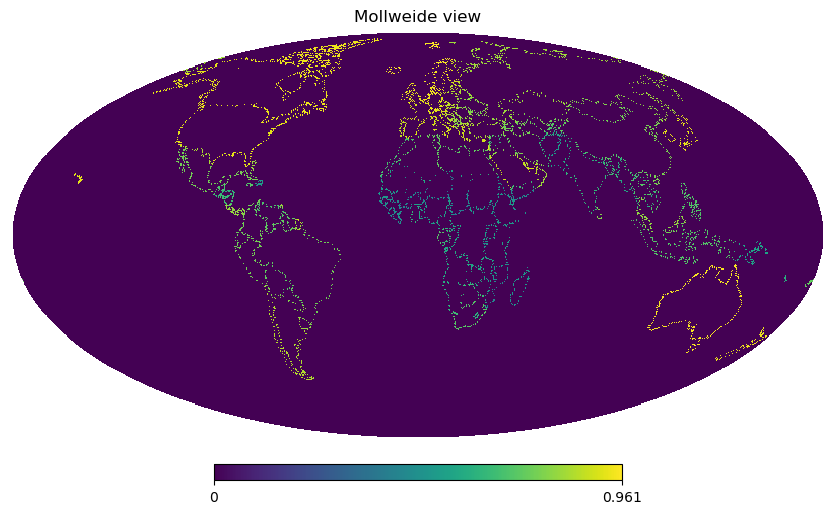

In [3]:
HDI_map=np.nan_to_num(HDI_map,nan=0)
hp.mollview(HDI_map,flip='geo',min=0)

In [4]:
# output_file = "HDI_border_map_fin.fits"

# # Save the HEALPix map to a FITS file
# hp.write_map(output_file, HDI_map)

setting the output map dtype to [dtype('float64')]
